<div>
    <img src="../figs/cammp.png" style="height:8em; width:auto; float: right; margin-right: 10px;">
    <img src="../figs/web-design.png" style="height:8em; width:auto; float: right; margin-right: 10px;">
</div>

# Worksheet 2 | Quantum Neural Networks & Hybrid PyTorch Integration

In this worksheet, we explore how to build trainable quantum circuits that function as neural networks, and how to integrate them into existing PyTorch pipelines. This is the key to bringing quantum computing into existing ML workflows.

**Topics covered:**
- **Variational Quantum Circuits**: Parametrized quantum circuits as trainable models
- **Cost Functions**: Defining objectives for quantum neural networks
- **Hybrid Architectures**: Combining quantum and classical layers
- **PyTorch Integration**: Using PennyLane with torch for seamless pipeline integration

**Learning Objectives:**
1. Understand how to create parametrized quantum circuits
2. Train quantum circuits using gradient-based optimization
3. Build hybrid quantum-classical neural networks
4. Integrate quantum layers into existing PyTorch pipelines

## Introduction

A **Variational Quantum Circuit (VQC)** or **Quantum Neural Network (QNN)** is a quantum circuit with parametrized gates that can be trained like classical neural networks. The key idea is:

1. **Encode** classical data into quantum states (see [Worksheet 1](01_DataEncoding.ipynb))
2. **Parametrize** the quantum circuit with trainable parameters $\theta$
3. **Measure** the quantum state to extract classical information
4. **Optimize** the parameters using gradient descent

The circuit can be written as:

$$f_\theta(x) = \langle 0|U^\dagger(x) V^\dagger(\theta)M V(\theta)U(x)|0\rangle$$

where $U(x)$ encodes the input, $V(\theta)$ is the parametrized circuit and $M$ is the measurement.

Let's start by setting up our environment:

In [4]:
# Setup: Import required libraries
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt

# PyTorch integration
import torch
import torch.nn as nn

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create quantum devices
dev = qml.device("default.qubit", wires=4)

print("Setup complete! Ready to build Quantum Neural Networks.")
print(f"PyTorch version: {torch.__version__}")
print(f"PennyLane version: {qml.__version__}")

Setup complete! Ready to build Quantum Neural Networks.
PyTorch version: 2.12.0
PennyLane version: 0.45.0


## 1) Variational Quantum Circuits

A VQC consists of three main components:

1. **Data Encoding Layer** $U(x)$: Encodes input data into quantum states
2. **Variational Layer** $V(\theta)$: Trainable parametrized gates
3. **Measurement**: Extracts classical information from the quantum state

Common variational layers include:
- **Single-qubit rotations**: [$R_X(\theta)$](https://docs.pennylane.ai/en/stable/code/api/pennylane.RX.html), [$R_Y(\theta)$](https://docs.pennylane.ai/en/stable/code/api/pennylane.RY.html), [$R_Z(\theta)$](https://docs.pennylane.ai/en/stable/code/api/pennylane.RZ.html)
- **Entangling layers**: [$CNOT$](https://docs.pennylane.ai/en/stable/code/api/pennylane.CNOT.html), [$CR_X$](https://docs.pennylane.ai/en/stable/code/api/pennylane.CRX.html), [$CZ$](https://docs.pennylane.ai/en/stable/code/api/pennylane.CZ.html), [$IsingXX$](https://docs.pennylane.ai/en/stable/code/api/pennylane.IsingXX.html) gates

A typical VQC architecture with data reuploading looks like:

<img src="figs/circuit_data_reuploading.png" width="70%" />

And a typical architecture without data reuploading is very similar:

<img src="figs/circuit_vqc.png" width="50%" />

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Build a Basic VQC</h3>
  
  Build a simple Variational Quantum Circuit for binary classification. The circuit should:
  
  1. Encode input data using angle encoding
  2. Apply 2 variational layers with rotations and entangling gates
  3. Measure the [expectation value](https://docs.pennylane.ai/en/stable/code/api/pennylane.expval.html) of [Pauli Z](https://docs.pennylane.ai/en/stable/code/api/pennylane.PauliZ.html) on the first qubit
  
  <hr>
  <i class="fas fa-wrench" style="font-size: 20px"></i> &nbsp; <strong>Variables:</strong>
  <ul>
    <li><code>weights</code>: shape (n_layers, n_qubits, 3) - rotation angles for each qubit</li>
    <li><code>features</code>: input data to encode</li>
  </ul>
  <hr>
  
  <a href="../help/tips_02_1a.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Hint</a>
</div>

In [159]:
# Exercise 1a: Build a Basic VQC

def variational_layer(weights, wires):
    """
    Apply a single variational layer.
    
    Args:
        weights: shape (n_qubits, 3) - rotation angles for each qubit
        wires: list of wire indices
    """
    # YOUR CODE HERE
    # Step 1: Apply rotations to each qubit
    # Step 2: Apply entangling gates (CNOT cascade)
    for i in range(len(wires)):
        qml.RZ(weights[i, 0], wires=wires[i])
        qml.RY(weights[i, 1], wires=wires[i])
        qml.RZ(weights[i, 2], wires=wires[i])
    # Apply CNOT gates for entanglement
    for i in range(len(wires) - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])
    qml.CNOT(wires=[wires[-1], wires[0]])

def vqc_classifier(features, weights):
    """
    Variational Quantum Circuit for binary classification.
    
    Args:
        features: input data (will be encoded using angle encoding)
        weights: shape (n_layers, n_qubits, 3) - trainable parameters
    
    Returns:
        Expectation value of Pauli Z on qubit 0
    """
    n_qubits = len(features)
    
    @qml.qnode(dev)
    def circuit():
        # YOUR CODE HERE
        # Step 1: Encode features using angle encoding
        # Step 2: Apply variational layers
        # Step 3: Measure expectation value of Z on qubit 0
        
        for layer in range(n_layers):
            for i, feature in enumerate(features):
                qml.RY(feature * np.pi, wires=i)
            variational_layer(weights[layer], list(range(n_qubits)))

        return qml.expval(qml.PauliZ(0))
    
    return circuit

# Test the VQC
n_qubits = 4
n_layers = 2
test_features = np.array([0.3, 0.7, 0.5, 0.9])
test_weights = np.random.rand(n_layers, n_qubits, 3)

output = vqc_classifier(test_features, test_weights)()
print(f"VQC output: {output:.4f}")
print("\nCircuit structure:")
print(qml.draw(vqc_classifier(test_features, test_weights))())

VQC output: -0.0965

Circuit structure:
0: ──RY(0.94)──RZ(0.96)──RY(0.25)──RZ(0.90)─╭●───────╭X──RY(0.94)──RZ(0.49)──RY(0.11)──RZ(0.65) ···
1: ──RY(2.20)──RZ(0.95)──RY(0.38)──RZ(0.33)─╰X─╭●────│───RY(2.20)──RZ(0.66)──RY(0.36)──RZ(0.10) ···
2: ──RY(1.57)──RZ(0.28)──RY(0.84)──RZ(0.68)────╰X─╭●─│───RY(1.57)──RZ(0.55)──RY(0.92)──RZ(0.79) ···
3: ──RY(2.83)──RZ(0.21)──RY(0.86)──RZ(0.19)───────╰X─╰●──RY(2.83)──RZ(0.57)──RY(0.08)──RZ(0.66) ···

0: ··· ─╭●───────╭X─┤  <Z>
1: ··· ─╰X─╭●────│──┤     
2: ··· ────╰X─╭●─│──┤     
3: ··· ───────╰X─╰●─┤     


## 2) Training a QNN

Training a QNN follows the same principles as classical neural networks:

1. **Forward Pass**: Compute predictions using the current parameters
2. **Loss Computation**: Calculate the error (e.g., cross-entropy, MSE)
3. **Backward Pass**: Compute gradients using the [**parameter-shift rule**](https://pennylane.ai/glossary/parameter_shift)
4. **Update**: Apply gradient descent or other optimizers

The **parameter-shift rule** allows us to compute quantum gradients analytically:

$$\frac{\partial f}{\partial \theta_i} = \frac{1}{2}\left(f(\theta_i + \pi/2) - f(\theta_i - \pi/2)\right)$$

This is implemented by PennyLane and optimized for execution on classical hardware! However, you are also able to execute the parameter-shift-rule as it would be used on a quantum computer. This is e.g. helpful to get information on how often the quantum computer would be called, but it takes way longer.

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Train a QNN for Classification</h3>
  
  Train the VQC from Exercise 1a) on a simple binary classification task:
  
  1. Generate synthetic data (two moons or blobs)
  2. Define a cost function (binary cross-entropy)
  3. Train the model using gradient descent: [`GradientDescentOptimizer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.GradientDescentOptimizer.html)
  4. Plot the training curve and decision boundary
  
  <hr>
  <i class="fas fa-wrench" style="font-size: 20px"></i> &nbsp; <strong>Variables:</strong>
  <ul>
    <li><code>n_samples</code>: number of training samples</li>
    <li><code>n_epochs</code>: number of training epochs</li>
    <li><code>learning_rate</code>: step size for gradient descent</li>
  </ul>
  <hr>
  
  <a href="help/tips_02_2a.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Hint</a>
</div>

In [180]:
# Exercise 2a: Train a QNN for Classification

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# Generate synthetic data
n_samples = 100
X, y = make_moons(n_samples=n_samples, noise=0.1, random_state=42)

# Normalize data to [0, 1] range
scaler = StandardScaler()
X_scaled = (X - X.min()) / (X.max() - X.min())

# YOUR CODE HERE
# Step 1: Define the cost function (binary cross-entropy)
def cost(weights, features, labels):
    """
    Compute the binary cross-entropy loss.
    """
    # TODO: Implement cost function
    pass

# Step 2: Initialize weights
n_qubits = 2
n_layers = 2
weights = None  # TODO: Initialize weights with proper shape and requires_grad=True

# Step 3: Training loop
n_epochs = 50
learning_rate = 0.1
costs = []

optimizer = None  # TODO: Initialize optimizer (e.g., qml.GradientDescentOptimizer)

for epoch in range(n_epochs):
    # TODO: Implement training loop
    # - Compute cost
    # - Compute gradients
    # - Update weights
    pass

print("Training complete!")
print(f"Final cost: {costs[-1]:.4f}")

Training complete!


IndexError: list index out of range

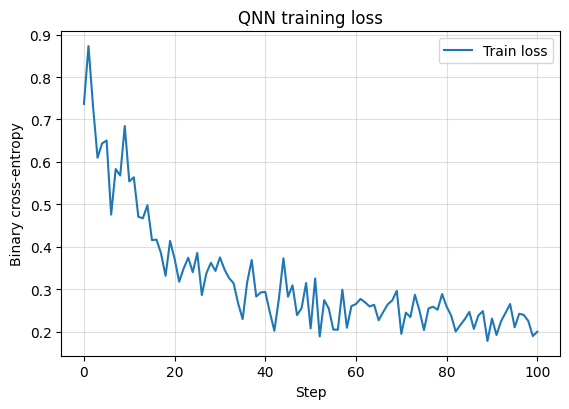

In [ ]:
# Plot the training curves
plt.figure(figsize=(5.8, 4.2))
plt.plot(np.arange(len(costs)), costs, label="Train loss")
plt.xlabel("Step")
plt.ylabel("Binary cross-entropy")
plt.title("QNN training loss")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

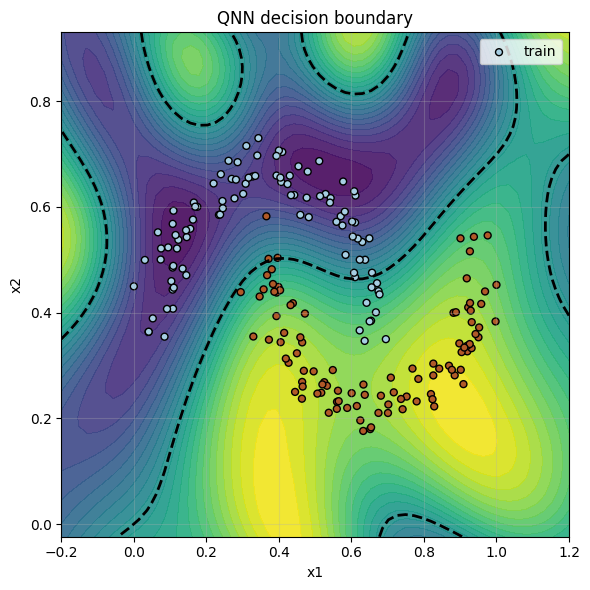

In [ ]:
# Decision boundary visualization
x_min, x_max = X_scaled[:, 0].min() - 0.2, X_scaled[:, 0].max() + 0.2
y_min, y_max = X_scaled[:, 1].min() - 0.2, X_scaled[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 60),
                     np.linspace(y_min, y_max, 60))
grid = np.c_[xx.ravel(), yy.ravel()]

probs_grid = np.array([(1 - vqc_classifier(g, weights)()) / 2.0 for g in grid]).reshape(xx.shape)

plt.figure(figsize=(6, 6))
cs = plt.contourf(xx, yy, probs_grid, levels=30, alpha=0.9)
plt.contour(xx, yy, probs_grid, levels=[0.5], colors="k", linestyles="--", linewidths=2)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.Paired,
            edgecolors='k', s=25, label="train")

plt.title("QNN decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3) PyTorch Integration

One of the most powerful features of PennyLane is its seamless integration with PyTorch. This allows you to:

1. **Use PyTorch optimizers** (Adam, SGD, etc.)
2. **Build hybrid architectures** with quantum and classical layers
3. **Leverage existing PyTorch pipelines** and infrastructure
4. **Train on GPUs** when available

The key is the [`qml.qnn.TorchLayer`](https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html) which wraps a QNode as a PyTorch module.

```python
# Create a quantum layer
qlayer = qml.qnn.TorchLayer(qnode, weights_shape)

# Use it like any PyTorch module
output = qlayer(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()
```

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Build a Hybrid QNN-PyTorch Model</h3>
  
  Build a hybrid model that combines classical and quantum layers:
  
  <ol>
    <li>Create a QNode for the quantum layer</li>
    <li>Wrap it as a TorchLayer</li>
    <li>Build a hybrid model with classical preprocessing and quantum classification</li>
    <li>Train using standard PyTorch training loop</li>
  </ol>
  
  <hr>
  <i class="fas fa-wrench" style="font-size: 20px"></i> &nbsp; <strong>Variables:</strong>
  <ul>
    <li><code>weight_shapes</code>: dictionary defining the shape of quantum weights</li>
    <li><code>device</code>: 'cuda' or 'cpu'</li>
  </ul>
  <hr>
  
  <a href="../help/tipps_02_2c.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Hint</a>
</div>

In [155]:
# Exercise 3a: Build a Hybrid QNN-PyTorch Model

# Step 1: Define the quantum circuit as a QNode
n_qubits = 2

@qml.qnode(dev, interface='torch', diff_method='backprop')
def quantum_circuit(inputs, weights):
    """
    Quantum circuit for classification.
    
    Args:
        inputs: encoded features (shape: n_qubits,)
        weights: trainable parameters (shape: n_layers, n_qubits, 3)
    """
    # YOUR CODE HERE
    # Step 1: Encode inputs using angle embedding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Step 2: Apply variational layers
    n_layers = weights.shape[0]
    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.RZ(weights[layer, i, 0], wires=i)
            qml.RY(weights[layer, i, 1], wires=i)
            qml.RZ(weights[layer, i, 2], wires=i)
        # simple entangling layer
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

    # Step 3: Return expectation value of Z on qubit 0
    return qml.expval(qml.PauliZ(0))

# Step 2: Define weight shapes for TorchLayer
weight_shapes = {"weights": (3, n_qubits, 3)}

# Step 3: Create the quantum layer
# YOUR CODE HERE
# qlayer = ...
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# Step 4: Build the hybrid model
class HybridQNN(nn.Module):
    def __init__(self, n_features=n_qubits):
        super().__init__()
        # Classical preprocessing layers
        # YOUR CODE HERE
        pass
        self.pre_net = nn.Sequential(nn.Linear(n_features, n_qubits), nn.ReLU())
        # Quantum layer
        self.qlayer = qlayer
        # Simple post-processing layer
        self.post = nn.Linear(1, 1)
    
    
    def forward(self, x):
        # x: tensor of shape (batch, n_features)
        x = self.pre_net(x)
        # TorchLayer has inconsistent handling for a batch size of 1,
        # so we evaluate one sample at a time to keep the qnode input shape safe.
        outputs = [self.qlayer(sample) for sample in x]
        q_out = torch.stack(outputs)
        if q_out.dim() == 1:
            q_out = q_out.unsqueeze(-1)
        out = self.post(q_out)
        return out

# Step 5: Train the hybrid model
# YOUR CODE HERE
# - Create model, optimizer, criterion
# - Training loop

print("Hybrid model created successfully!")

# Step 5: (Optional) Example usage
model = HybridQNN()
sample = torch.tensor([[0.3, 0.7]], dtype=torch.float32)
out = model(sample)
print("Hybrid model created successfully! Output example:", out.detach().numpy())

# Training placeholder:
# - Create optimizer: optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# - Define loss: criterion = nn.BCEWithLogitsLoss() or MSELoss()
# - Implement training loop feeding batches through the model and updating parameters

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

X_train = torch.tensor(X_scaled, dtype=torch.float32)
y_train = torch.tensor(2 * y - 1, dtype=torch.float32)

dataset = torch.utils.data.TensorDataset(X_train, y_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

n_epochs = 40
for epoch in range(n_epochs):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        out = model(xb).squeeze(-1)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.shape[0]
    epoch_loss /= len(dataset)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, loss: {epoch_loss:.4f}")

print("Hybrid model training complete!")

# Example usage
model.eval()
sample = torch.tensor([[0.3, 0.7]], dtype=torch.float32)
out = model(sample).detach().numpy()
print("Hybrid model output example:", out)


Hybrid model created successfully!
Hybrid model created successfully! Output example: [[0.49921283]]
Epoch 1/40, loss: 1.1401
Epoch 10/40, loss: 0.6466
Epoch 20/40, loss: 0.5179
Epoch 30/40, loss: 0.4635
Epoch 40/40, loss: 0.4161
Hybrid model training complete!
Hybrid model output example: [[-0.9132572]]


## 4) Best Practices for Hybrid Models

**Key Considerations:**

1. **Data Encoding**: Choose appropriate encoding (see [Worksheet 1](01_DataEncoding.ipynb))
2. **Measurement Strategy**: Single-qubit measurements are often sufficient
3. **Circuit Depth**: Start shallow, increase as needed
4. **Batch Processing**: Use vectorized quantum circuits for efficiency
5. **Hardware Efficiency**: Consider circuit transpilation for real devices

**Common Pitfalls:**
- Vanishing gradients in deep circuits (use data reuploading!)
- Barren plateaus (start with shallow circuits)
- Measurement overhead (use shadow tomography for speed)

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Integrate QNN into Existing Pipeline</h3>
  
  This exercise demonstrates how to integrate a quantum layer into an existing ML pipeline:
  
  <ol>
    <li>Load a real dataset (e.g., breast cancer or wine dataset)</li>
    <li>Build a preprocessing pipeline with StandardScaler</li
    <li>Add a quantum layer as a feature extractor</li>
    <li>Train the full pipeline using PyTorch</li>
    <li>Compare with a purely classical baseline</li>
  </ol>
  
  <hr>
  <i class="fas fa-wrench" style="font-size: 20px"></i> &nbsp; <strong>Variables:</strong>
  <ul>
    <li><code>dataset</code>: 'breast_cancer' or 'wine'</li>
    <li><code>test_size</code>: fraction of data for testing</li>
  </ul>
  <hr>
  
  <a href="../help/tipps_02_2d.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Hint</a>
</div>

In [5]:
# Exercise 4a: Integrate QNN into Existing Pipeline

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# YOUR CODE HERE
# Step 1: Preprocess data (StandardScaler)

# Step 2: Create quantum feature extractor

# Step 3: Build hybrid model

# Step 4: Train and evaluate

# Step 5: Compare with classical baseline

print("Pipeline integration complete!")

<hr>

## Summary

In this worksheet, we learned how to build and train Quantum Neural Networks:

1. **Variational Quantum Circuits**: Parametrized quantum circuits as trainable models
2. **Training**: Using the parameter-shift rule for gradient computation
3. **PyTorch Integration**: Seamless combination of quantum and classical layers
4. **Pipeline Integration**: Adding quantum components to existing ML workflows

**Key Takeaways:**
- QNNs can be trained like classical neural networks
- PennyLane provides automatic differentiation for quantum circuits
- Hybrid models leverage both quantum and classical strengths
- Quantum layers can be integrated into existing PyTorch pipelines

<hr>

## Discussion Questions

1. What are the advantages of hybrid quantum-classical models?
2. When would you choose a QNN over a classical neural network?
3. What challenges might arise when scaling QNNs to larger datasets?

<hr>

## Next Steps

Continue to:
- [Worksheet 3: Quantum CNNs](./03_QCNN.ipynb) - Hierarchical feature extraction
- [Worksheet 4: Quantum Kernels](./04_QKM.ipynb) - Kernel methods in quantum space

---

___
<hr>
<img src = "../figs/CC-BY-SA.png" style="height:3em; width:auto"> 
This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/">Creative Commons Attribution-ShareAlike 4.0 International License</a>. </br>

Workshop: Coding the QML Future</br>
Authors: Eileen Kuehn, Gabriel Mejia Ruiz (KIT/SCC)